In [1]:
import sys
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score
from sklearn import set_config
set_config(transform_output="pandas")

sys.path.append(os.path.abspath('../src'))
from sklearn.model_selection import train_test_split
from DataLoader import DataLoader
from DataSplitter import DataSplitter
from Transformer import Transformer
from InteractionsTransformer import InteractionsTransformer
from PreProcessor import PreProcessor
from ModelCollection import ModelCollection
from PipelineBuilder import PipelineBuilder
from CrossValidation import CrossValidation

In [2]:
config_path = "../src/config.jsonc"
path_train, path_test = "../data/train.csv", "../data/test.csv"
data_loader = DataLoader(path_train, path_test)
train, test = data_loader.load()

In [3]:
train

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1456,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1456,1457,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1457,1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500
1458,1459,20,RL,68.0,9717,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,142125


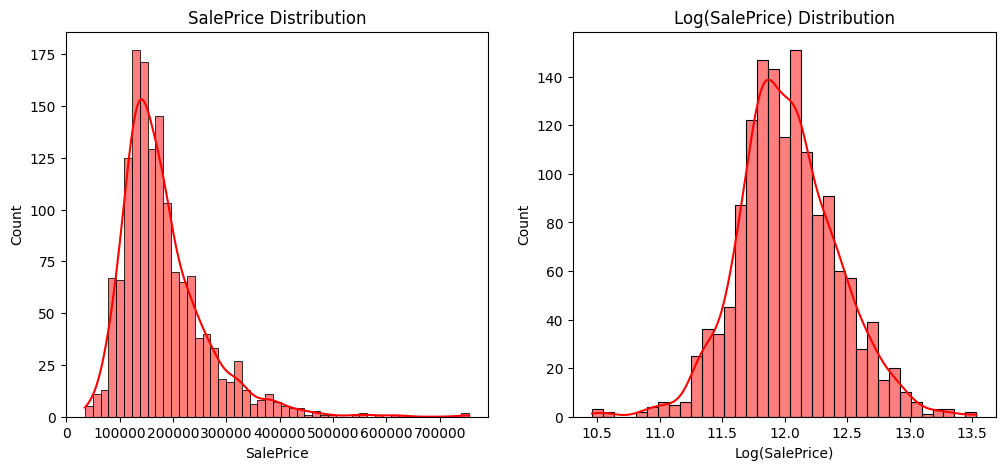

In [4]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12, 5))
sns.histplot(ax=ax[0], data=train['SalePrice'], kde=True, color='red')#, stat='density')
sns.histplot(ax=ax[1], data=np.log(1+train['SalePrice']), kde=True, color='red')#, stat='density')
ax[0].set_title('SalePrice Distribution')
ax[1].set_title('Log(SalePrice) Distribution')
ax[1].set_xlabel('Log(SalePrice)')
#ax[0].legend()
#ax[1].legend()
plt.show()

In [5]:
train.shape
num_cols = train.select_dtypes(include='number').columns.tolist(), 
cat_cols = train.select_dtypes(include=['category', 'object']).columns.tolist()
num_cols, cat_cols

((['Id',
   'MSSubClass',
   'LotFrontage',
   'LotArea',
   'OverallQual',
   'OverallCond',
   'YearBuilt',
   'YearRemodAdd',
   'MasVnrArea',
   'BsmtFinSF1',
   'BsmtFinSF2',
   'BsmtUnfSF',
   'TotalBsmtSF',
   '1stFlrSF',
   '2ndFlrSF',
   'LowQualFinSF',
   'GrLivArea',
   'BsmtFullBath',
   'BsmtHalfBath',
   'FullBath',
   'HalfBath',
   'BedroomAbvGr',
   'KitchenAbvGr',
   'TotRmsAbvGrd',
   'Fireplaces',
   'GarageYrBlt',
   'GarageCars',
   'GarageArea',
   'WoodDeckSF',
   'OpenPorchSF',
   'EnclosedPorch',
   '3SsnPorch',
   'ScreenPorch',
   'PoolArea',
   'MiscVal',
   'MoSold',
   'YrSold',
   'SalePrice'],),
 ['MSZoning',
  'Street',
  'Alley',
  'LotShape',
  'LandContour',
  'Utilities',
  'LotConfig',
  'LandSlope',
  'Neighborhood',
  'Condition1',
  'Condition2',
  'BldgType',
  'HouseStyle',
  'RoofStyle',
  'RoofMatl',
  'Exterior1st',
  'Exterior2nd',
  'MasVnrType',
  'ExterQual',
  'ExterCond',
  'Foundation',
  'BsmtQual',
  'BsmtCond',
  'BsmtExposure',


In [6]:
with pd.option_context('display.max_rows', None):
    print(train['LotShape'].value_counts(dropna=False))

LotShape
Reg    925
IR1    484
IR2     41
IR3     10
Name: count, dtype: int64


In [7]:
idx = train.isna().sum().index
Nans_df = pd.DataFrame(index=idx, columns=['train', 'test'])
Nans_df['train'] = train.isna().sum()/train.shape[0]
Nans_df['test'] = test.isna().sum()/test.shape[0]
with pd.option_context('display.max_rows', None):
    print(Nans_df)

                  train      test
Id             0.000000  0.000000
MSSubClass     0.000000  0.000000
MSZoning       0.000000  0.002742
LotFrontage    0.177397  0.155586
LotArea        0.000000  0.000000
Street         0.000000  0.000000
Alley          0.937671  0.926662
LotShape       0.000000  0.000000
LandContour    0.000000  0.000000
Utilities      0.000000  0.001371
LotConfig      0.000000  0.000000
LandSlope      0.000000  0.000000
Neighborhood   0.000000  0.000000
Condition1     0.000000  0.000000
Condition2     0.000000  0.000000
BldgType       0.000000  0.000000
HouseStyle     0.000000  0.000000
OverallQual    0.000000  0.000000
OverallCond    0.000000  0.000000
YearBuilt      0.000000  0.000000
YearRemodAdd   0.000000  0.000000
RoofStyle      0.000000  0.000000
RoofMatl       0.000000  0.000000
Exterior1st    0.000000  0.000685
Exterior2nd    0.000000  0.000685
MasVnrType     0.597260  0.612748
MasVnrArea     0.005479  0.010281
ExterQual      0.000000  0.000000
ExterCond     

In [8]:
#X_train = train.drop(columns=['SalePrice'])
#y_train = train['SalePrice']

train['SalePrice'] = np.log1p(train['SalePrice'])
data_splitter = DataSplitter("SalePrice", test_size=0.2)
X_train, X_test, y_train, y_test = data_splitter.split(train)

transformer = Transformer(config_path=config_path)
preprocessor = PreProcessor(df=X_train, config_path=config_path)
preprocessor = preprocessor.build()
inter_transformer = InteractionsTransformer()
model_collection = ModelCollection()
model = model_collection.get('Ridge')
pipeline = PipelineBuilder(transformer=transformer, preprocessor=preprocessor, interactions=inter_transformer, model=model)
pipeline = pipeline.build()
pipeline.fit(X_train, y_train)

pred = pd.Series(pipeline.predict(X_test), index=y_test.index)
results = pd.DataFrame({'y_test': y_test.values, 'pred': pred.values.astype(int)})
results['Diff%'] = 100 * abs((results['y_test']-results['pred']) / results['y_test'])
print(results.describe())

# Evaluation through cross validation
n_folds = 5
cv = CrossValidation(n_folds, pipeline)
X, y = train.drop(columns=['SalePrice']), train['SalePrice']
score_stats = cv.evaluate(X,y)
print(score_stats)

X_train_df = pipeline.named_steps["features"].transform(X_train)
X_train_df = pipeline.named_steps["preprocess"].transform(X_train_df)
X_train_df

           y_test        pred       Diff%
count  292.000000  292.000000  292.000000
mean    11.997654   11.462329    4.523295
std      0.432727    0.526238    2.531490
min     10.471978   10.000000    0.007482
25%     11.751950   11.000000    2.164631
50%     11.945687   11.000000    4.993554
75%     12.250929   12.000000    6.819481
max     13.534474   13.000000    9.936473
{'mean_rmse': np.float64(0.13426216332996244), 'std_rmse': np.float64(0.03065458983302951)}


,num__LotArea,num__2ndFlrSF,num__BsmtFinSF1,num__MSSubClass,num__TotalBsmtSF,num__WoodDeckSF,num__MoSold,num__KitchenAbvGr,num__BsmtUnfSF,num__PoolArea,...,na_as_none__MasVnrType_None,na_as_none__MasVnrType_Stone,na_as_none__GarageType_2Types,na_as_none__GarageType_Attchd,na_as_none__GarageType_Basment,na_as_none__GarageType_BuiltIn,na_as_none__GarageType_CarPort,na_as_none__GarageType_Detchd,na_as_none__GarageType_None,na_as_zero__GarageYrBlt
254,-0.167026,-0.801923,1.037269,-0.866764,0.572612,1.188402,-0.133417,-0.212757,-0.400282,-0.070993,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.192392
1066,-0.301310,0.955088,-0.971996,0.074110,-0.596547,-0.740157,-0.508010,-0.212757,0.511920,-0.070993,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.272225
638,-0.082046,-0.801923,-0.971996,-0.631546,-0.603357,1.790113,-0.508010,-0.212757,0.505196,-0.070993,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,-4.147410
799,-0.465400,0.989227,0.267995,-0.161109,-0.750921,-0.740157,-0.133417,-0.212757,-0.915776,-0.070993,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.152476
380,-1.171176,0.711564,-0.496920,-0.161109,-0.081209,-0.740157,-0.508010,-0.212757,0.532091,-0.070993,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.119212
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1095,0.033523,-0.801923,-0.919694,-0.866764,0.572612,-0.740157,-1.257196,-0.212757,1.612389,-0.070993,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.301053
1130,-0.309477,0.684253,0.383495,-0.161109,0.136732,2.584680,2.114141,-0.212757,-0.158223,-0.070993,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.245614
1294,-0.220290,-0.801923,-0.608062,-0.866764,-0.448983,-0.740157,-0.882603,-0.212757,0.283309,-0.070993,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.192392
860,-0.350081,0.367900,-0.971996,-0.161109,-0.340013,-0.740157,-0.133417,-0.212757,0.765184,-0.070993,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.121430


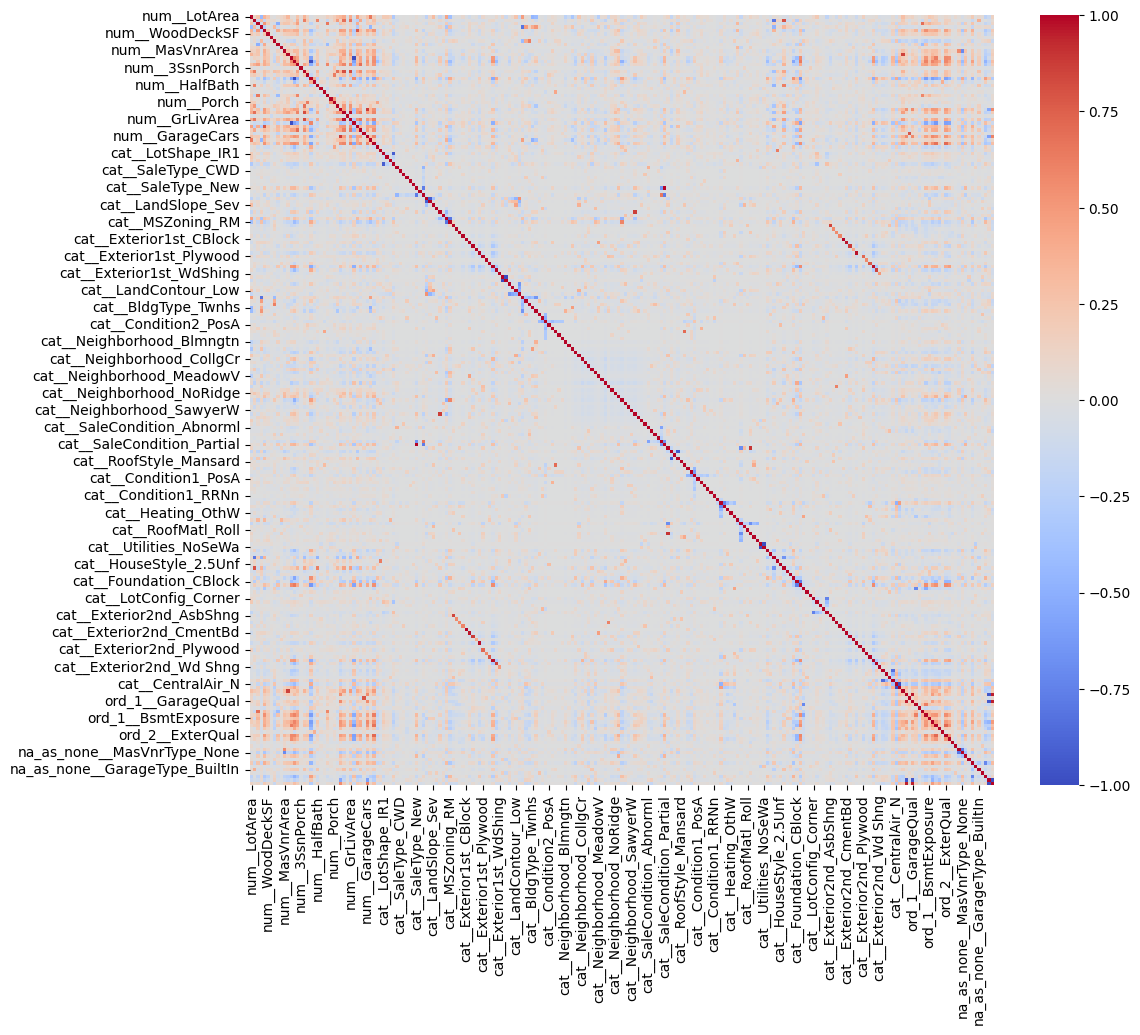

In [9]:
plt.figure(figsize=(12, 10))
sns.heatmap(X_train_df.corr(), cmap="coolwarm", center=0)
plt.show()

In [10]:
corr_with_target = X_train_df.corrwith(y_train)
with pd.option_context('display.max_rows', None):
    print(corr_with_target.sort_values(ascending=False))
    print(len(corr_with_target))

num__OverallQual                  0.807946
num__GrLivArea                    0.723567
num__SqFeet                       0.697328
num__GarageCars                   0.684451
ord_2__KitchenQual                0.667939
ord_2__ExterQual                  0.660159
num__Baths                        0.659371
num__GarageArea                   0.654520
ord_1__BsmtQual                   0.622365
ord_1__GarageFinish               0.607353
num__TotalBsmtSF                  0.597214
num__1stFlrSF                     0.595208
num__FullBath                     0.583747
num__YearBuilt                    0.576725
num__YearRemodAdd                 0.562152
ord_1__FireplaceQu                0.541509
num__TotRmsAbvGrd                 0.520082
cat__Foundation_PConc             0.518922
ord_2__HeatingQC                  0.484609
num__Fireplaces                   0.481761
num__MasVnrArea                   0.419978
num__LotArea                      0.411305
na_as_none__GarageType_Attchd     0.405525
ord_1__Gara

In [11]:
# Skewness of raw features
column_skewness = X_train_df.skew(numeric_only=True)
with pd.option_context('display.max_rows', None):
    print(column_skewness.sort_values(ascending=False))

cat__Condition2_RRAn              34.176015
cat__Condition2_RRAe              34.176015
cat__Exterior1st_CBlock           34.176015
cat__Condition2_RRNn              34.176015
cat__Heating_Floor                34.176015
cat__Exterior2nd_Other            34.176015
cat__Exterior2nd_CBlock           34.176015
cat__Condition1_RRNe              34.176015
cat__Exterior1st_AsphShn          34.176015
cat__Utilities_NoSeWa             34.176015
cat__Condition2_PosA              34.176015
cat__RoofMatl_ClyTile             34.176015
cat__Exterior1st_ImStucc          34.176015
cat__Exterior1st_Stone            34.176015
cat__Neighborhood_Blueste         34.176015
cat__RoofMatl_Metal               34.176015
cat__RoofMatl_Roll                34.176015
cat__RoofStyle_Shed               24.134984
cat__SaleType_Con                 24.134984
cat__Exterior1st_BrkComm          24.134984
cat__SaleType_Oth                 24.134984
cat__Condition2_PosN              24.134984
cat__Heating_OthW               

In [12]:
X_train_df[['cat__Utilities_AllPub', 'cat__Street_Pave', 'num__MiscVal', 'num__LotArea']].value_counts()

cat__Utilities_AllPub  cat__Street_Pave  num__MiscVal  num__LotArea
1.0                    1.0               -0.092740      0.091442       23
                                                       -0.465400       18
                                                       -0.818293       14
                                                       -0.167026       11
                                                       -0.033481       10
                                                                       ..
                                          3.525186      1.162203        1
                                          4.429667     -0.024469        1
                                          6.238630     -0.951830        1
                                          14.921653     1.401661        1
                                          0.811741      0.250282        1
Name: count, Length: 905, dtype: int64

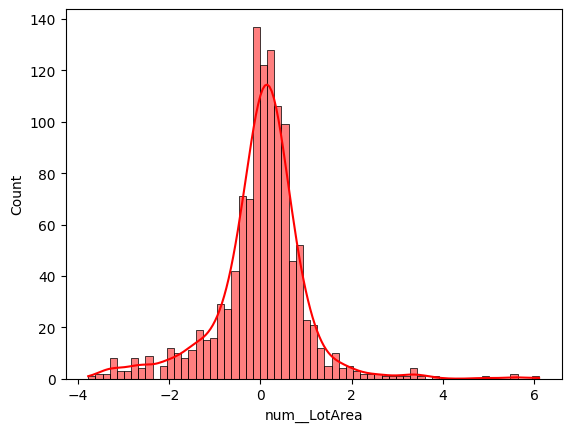

In [13]:
sns.histplot(data=X_train_df['num__LotArea'], kde=True, color='red')
#plt.xlim(min(X_train_df['num__LotArea'])-0.2, 6) 
plt.show()

In [14]:
# We'll run a linear regression of target against raw feature, then against log feature, and compare the CVs
# If after applying log to the feature we notice an improvement in CV score, this is a signal that the 
# feature might be log transformed

column_skewness = X_train_df.skew(numeric_only=True)
num_cols = [col for col in list(X_train_df.columns) if col[:3]=="num"]
num_cols_names = [col[5:] for col in num_cols]

logX_train = X_train.copy()
logX_train = pipeline.named_steps["features"].transform(logX_train)
logX_train[num_cols_names] = np.log1p(logX_train[num_cols_names])

logpreprocessor = PreProcessor(df=X_train, config_path=config_path)
logpreprocessor = logpreprocessor.build()
logpreprocessor.fit(logX_train, y_train)
logX_train_df = logpreprocessor.transform(logX_train)

cv_scores, y = {}, y_train
for col in num_cols:
    if(abs(column_skewness[col]) > 1):
        X = X_train_df[[col]].copy()
        score_raw = cross_val_score(LinearRegression(), X, y, cv=5, scoring="neg_root_mean_squared_error")
        score_raw_mean, score_raw_std = float(int(1000*score_raw.mean()))/1000, float(int(1000*score_raw.std()))/1000 
        X_log = logX_train_df[[col]].copy()
        score_log = cross_val_score(LinearRegression(), X_log, y, cv=5, scoring="neg_root_mean_squared_error")
        score_log_mean, score_log_std = float(int(1000*score_log.mean()))/1000, float(int(1000*score_log.std()))/1000 
        skewness = float(int(1000*column_skewness[col]))/1000
        cv_scores[col] = [skewness, score_raw_mean, score_raw_std, score_log_mean, score_log_std]

cv_scores

C:\Users\felip\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\pandas\core\internals\blocks.py:395: RuntimeWarning: divide by zero encountered in log1p
  result = func(self.values, **kwargs)


ValueError: Input X contains infinity or a value too large for dtype('float64').

$\textbf{Candidates for log transform:}$

LotArea(YES), OpenPorchSF(visual insapection -> NO), GrLivArea(YES), 1stFlrSF(YES), LotFrontage(YES)

In [ ]:
# Checking visually
cols = cv_scores.keys()
fig, ax = plt.subplots(nrows=len(cols), ncols=2, figsize=(12, 5*len(cols)))
for i, col in enumerate(cols):
    x, y = pd.DataFrame({"x": X_train_df[col]}), y_train
    
    ols = LinearRegression()
    ols.fit(x, y)
    ax[i, 0].plot(x, ols.predict(x), color='black')
    ax[i, 0].scatter(x, y)
    ax[i, 0].set_ylabel('Target')
    ax[i, 0].set_xlabel(f'Raw Feature Value - {col}')

    
    ols = LinearRegression()
    x = pd.DataFrame({"x": logX_train_df[col]})
    ols.fit(x, y)
    ax[i, 1].plot(x, ols.predict(x), color='black')
    ax[i, 1].scatter(x, y)
    ax[i, 1].set_ylabel('Target')
    ax[i, 1].set_xlabel(f'Log Feature Value - {col}')

plt.subplots_adjust(hspace=0.4) 
fig.suptitle("Univariate Linear Regression against (raw vs log) Feature", fontsize=12, y=0.887)
plt.show()

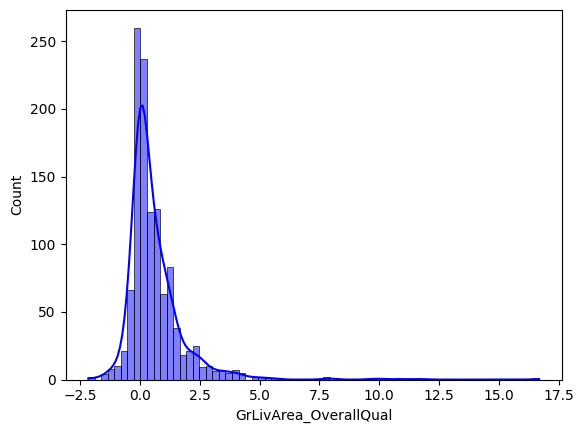

GrLivArea_OverallQual
 1.285728    10
 1.200612     7
 0.144421     6
 2.432086     6
 0.823362     6
             ..
 1.195215     1
 2.325741     1
 0.026021     1
-1.483353     1
 0.240049     1
Name: count, Length: 973, dtype: int64

In [15]:
# interactions:
inter_name = "GrLivArea_OverallQual"
X_train_df_inter = pipeline.named_steps["interactions"].transform(X_train_df)
sns.histplot(data=X_train_df_inter[inter_name], kde=True, color='blue')
#plt.xlim(-5, 5) 
plt.show()

X_train_df_inter[inter_name].value_counts()